# Convert AUDIO rows in `ble_*.csv` to WAV

This notebook scans current directory for `ble_*.csv`, extracts rows that contain `AUDIO`, takes 80 samples per AUDIO row, concatenates them, and writes 16-bit mono WAV at 16 kHz.

Found 1 file(s) in: c:\Users\24707\OneDrive - HKUST Connect\Desktop\WentaoInhaler_DueAudioChannel_nRF5340Firm\tools\openearable-web-bluetooth
[OK] ble_test_1781079923626.csv -> ble_test_1781079923626.wav | AUDIO rows: 4501, samples: 540120, sample_rate: 16000 Hz, duration: 33.76s


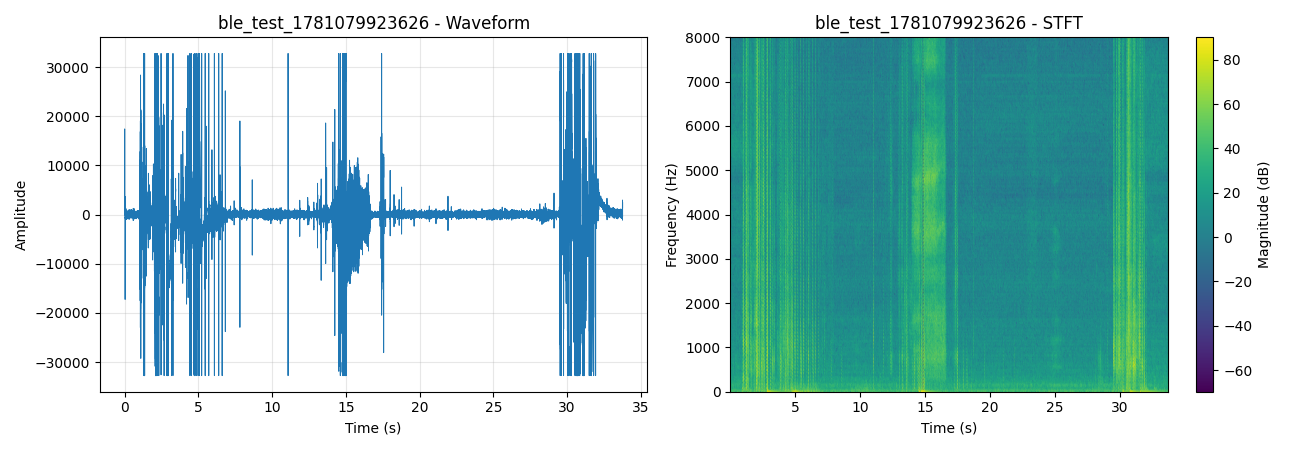

In [2]:
from pathlib import Path
import csv
import re
import wave
from array import array

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft

# Force widget backend as requested.
get_ipython().run_line_magic('matplotlib', 'widget')

SAMPLE_RATE = 16000
DEFAULT_SAMPLES_PER_AUDIO_ROW = 80
AUDIO_TAG = "AUDIO"


def extract_audio_row_samples(row):
    """Extract samples from rows whose 2nd column is AUDIO.

    New CSV format:
      timestamp_us, type, format, data...

    - row[1] is AUDIO tag
    - row[2] is format metadata (contains numbers like raw_u32_us), which must be ignored
    - actual sample columns start at row[3]
    """
    if len(row) < 4:
        return []

    if str(row[1]).strip().upper() != AUDIO_TAG:
        return []

    fmt = str(row[2]).strip().lower()
    m = re.search(r"_(\d+)_samples", fmt)
    expected = int(m.group(1)) if m else DEFAULT_SAMPLES_PER_AUDIO_ROW

    data_cells = row[3:]
    nums = []
    for cell in data_cells:
        text = str(cell).strip()
        if not text:
            continue
        try:
            nums.append(int(round(float(text))))
        except ValueError:
            # In case one cell contains a mini comma-separated chunk, parse robustly.
            nums.extend(
                int(round(float(mm.group(0))))
                for mm in re.finditer(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", text)
            )

    if len(nums) < expected:
        return []

    return nums[:expected]


def to_int16(samples):
    out = array("h")
    for v in samples:
        if v > 32767:
            v = 32767
        elif v < -32768:
            v = -32768
        out.append(int(v))
    return out


def plot_signal_and_stft(pcm, sample_rate, title_prefix):
    if len(pcm) == 0:
        return

    signal = np.asarray(pcm, dtype=np.float32)
    t = np.arange(signal.size) / float(sample_rate)

    nperseg = min(512, len(signal))
    if nperseg < 32:
        nperseg = len(signal)
    noverlap = max(0, nperseg // 2)

    f, tt, zxx = stft(
        signal,
        fs=sample_rate,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap,
        boundary=None,
        padded=False,
    )
    stft_db = 20 * np.log10(np.maximum(np.abs(zxx), 1e-10))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(t, signal, linewidth=0.7)
    axes[0].set_title(f"{title_prefix} - Waveform")
    axes[0].set_xlabel("Time (s)")
    axes[0].set_ylabel("Amplitude")
    axes[0].grid(True, alpha=0.3)

    mesh = axes[1].pcolormesh(tt, f, stft_db, shading='gouraud')
    axes[1].set_title(f"{title_prefix} - STFT")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Frequency (Hz)")
    fig.colorbar(mesh, ax=axes[1], label='Magnitude (dB)')

    plt.tight_layout()
    plt.show()


def convert_file(csv_path: Path):
    all_samples = []
    audio_rows = 0

    with csv_path.open("r", encoding="utf-8", errors="ignore", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            samples = extract_audio_row_samples(row)
            if samples:
                audio_rows += 1
                all_samples.extend(samples)

    if not all_samples:
        print(f"[SKIP] {csv_path.name}: no valid AUDIO rows found")
        return None

    wav_path = csv_path.with_suffix(".wav")
    pcm = to_int16(all_samples)

    # Store WAV with fixed 16 kHz sample rate.
    with wave.open(str(wav_path), "wb") as wf:
        wf.setnchannels(1)
        wf.setsampwidth(2)  # 16-bit
        wf.setframerate(SAMPLE_RATE)
        wf.writeframes(pcm.tobytes())

    duration = len(pcm) / SAMPLE_RATE if SAMPLE_RATE > 0 else 0
    print(
        f"[OK] {csv_path.name} -> {wav_path.name} | "
        f"AUDIO rows: {audio_rows}, samples: {len(pcm)}, "
        f"sample_rate: {SAMPLE_RATE} Hz, duration: {duration:.2f}s"
    )

    plot_signal_and_stft(pcm, SAMPLE_RATE, csv_path.stem)
    return wav_path


base = Path.cwd()
csv_files = sorted(base.glob("ble_*.csv"))

if not csv_files:
    print(f"No ble_*.csv found in: {base}")
else:
    print(f"Found {len(csv_files)} file(s) in: {base}")
    _ = [convert_file(p) for p in csv_files]
